## Introduction

Support Vector Machines (SVMs) are supervised ML algorithms that find the optimal hyperplane maximizing the margin between classes. Through the kernel trick, SVMs can capture non-linear relationships without explicitly computing a high-dimensional feature mapping, which makes them a reasonable classical-ML candidate for financial return data where the two classes overlap heavily and are not linearly separable.

This notebook builds an SVM-based directional signal for SPY: predicting whether tomorrow's close will exceed today's close by more than 0.25%. The 0.25% threshold (rather than a plain sign(return) label) is deliberate — it filters out noise-level moves that aren't economically meaningful after transaction costs, turning this into a "meaningfully directional move" classifier rather than a symmetric coin-flip.

**Pipeline overview:**
1. Stationary feature engineering (ratios/returns, not raw price levels — see rationale below)
2. Leakage-free train/test split, followed by two feature-reduction stages fit on the training set only: correlation-based redundancy filtering, then L1 (Lasso) regularized logistic regression
3. Outlier-aware dual scaling (RobustScaler / StandardScaler) matched to each feature's empirical tail behavior
4. SVM hyperparameter tuning via exhaustive grid search with `TimeSeriesSplit`, scored on F0.5 (precision-weighted — rationale below)
5. Out-of-sample-only backtesting and evaluation against buy-and-hold

**SPY** was chosen because it's the most liquid ETF in existence (minimal transaction cost/slippage distortion in a backtest) and, as a broad index, has lower idiosyncratic noise than a single stock.


### Setup

In [1]:
# Importing Necessary Libraries
# Importing Necessary libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Quantmod
import quantmod.charts
from quantmod.datasets import fetch_historical_data
from quantmod.timeseries import OpCl, HiLo, Gap, dailyReturn, lag, lead
from quantmod.indicators import SMA, BBands

# scikit-learn
import sklearn

# Data Preprocessing 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# ColumnTransformer is used to select the columns to be scaled, it is used to apply different scalers to different columns
from sklearn.compose import ColumnTransformer

# Pipeline is used to chain together multiple steps of the pipeline, it helps prevent data leakage
from sklearn.pipeline import Pipeline


# Logistic Regression for Lasso
from sklearn.linear_model import LogisticRegression


# train_test_split is used to split the data into training and testing sets
from sklearn.model_selection import train_test_split


# GridSearchCV to find the best hyperparameters for the model, TimeSeriesSplit to split the data into training and testing sets
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV


# Classifier
from sklearn.svm import SVC

# Sequential Feature Selector
from sklearn.feature_selection import SequentialFeatureSelector

# Compute sample weight
from sklearn.utils.class_weight import compute_sample_weight

# Metrics
from sklearn.metrics import (
                            accuracy_score,
                            RocCurveDisplay,
                            ConfusionMatrixDisplay,
                            classification_report, f1_score, fbeta_score, confusion_matrix,
                            roc_auc_score, make_scorer, precision_score, recall_score
                            )


# Import Financial Data
import yfinance as yf

# Import Plotting libraries

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# To enable plots in html output
import plotly.io as pio
pio.renderers.default = "notebook"


### Data

Daily SPY OHLCV, 2016–2020. A single, liquid, broad-index ETF keeps the focus on methodology rather than instrument-specific quirks (illiquidity, corporate actions, idiosyncratic noise) that would need separate handling.

In [2]:
spy = yf.download("SPY", start = '2020-01-01', end = '2026-06-30', auto_adjust = True)


spy.index = pd.to_datetime(spy.index)

spy.columns = spy.columns.get_level_values(0)

spy.columns = spy.columns.str.lower()

spy = spy[['open', 'high', 'low', 'close', 'volume']]

print(spy.head())


[*********************100%***********************]  1 of 1 completed

Price             open        high         low       close    volume
Date                                                                
2020-01-02  294.912966  296.143523  293.992323  296.125275  59151200
2020-01-03  292.743505  295.004083  292.688816  293.882904  77709700
2020-01-06  292.132782  295.086123  292.014280  295.004089  55653900
2020-01-07  294.439034  294.913042  293.728050  294.174713  40496400
2020-01-08  294.366120  296.954832  294.120020  295.742523  68296000


In [4]:
spy.index.rename('date', inplace=True)
fig = px.line(spy, y = 'close', x = spy.index, title = 'SPY Closing Price')

fig.show()

In [5]:
fig = make_subplots(rows = 3, cols = 2, subplot_titles = spy.columns)

for i, col in enumerate(spy.columns):
    row = i // 2 +1
    col_no = i % 2 +1
    fig = fig.add_trace(go.Histogram(x = spy[col], name = col), row = row, col = col_no)

fig.update_layout(title = 'OHLCV Distribution')
fig.show()




### Feature engineering — stationarity is the organizing principle

Every feature below is deliberately constructed as a **ratio or return**, not a raw price level. This matters because SVM is a distance-based kernel method: the RBF kernel computes `exp(-γ‖xᵢ-xⱼ‖²)`, and if a feature's scale drifts with the underlying trend (e.g. a raw moving average on a stock that goes from \$50 to \$300 over the sample), the kernel's notion of "similarity" between an early-period point and a late-period point degrades even when the *economically relevant* relationship (price relative to its own trend) hasn't changed at all. The fix used throughout is to normalize every price-level construct against a stable, contemporaneous reference — usually `open` or `close` — before it reaches the model, rather than relying on the scaler to fix it downstream (a static-statistic scaler fit on one price regime doesn't generalize to a different one either).

**Feature groups and what each is meant to capture:**

| Feature(s) | Type | Captures |
|---|---|---|
| `OC`, `HC` (ratio to `open`) | Price-action | Intraday body / range, normalized so a \$1 move means the same thing at \$50 or \$500 |
| `GAP` | Price-action | Overnight sentiment shift (information arriving after the close) |
| `RET`, `RET_lag1/2` | Return / autocorrelation | Short-memory momentum or mean-reversion at 1–2 day horizon |
| `PCHG(i)`, `RET(i)` (rolling sum) | Momentum | Multi-horizon cumulative return, letting the model discover which lookback (3/7/14 days) matters rather than assuming one |
| `VCHG(i)` | Volume | Participation behind a price move — confirms or contradicts it |
| `STD(i)` | Volatility | Realized volatility / regime detection |
| `PCBBAND(i)` (%B) | Volatility + mean-reversion | Where price sits *within* its own Bollinger Band, `(close-LB)/(UB-LB)` — bounded ~0–1, uses both band edges rather than distance from one |
| `EMA(i)`, `MOM(i)` | Trend | `close/EMA - 1` and `close/SMA - 1` — distance from trend as a ratio, not the trend level itself |

Raw `SMA`, `LB`, `UB` are computed only as intermediate steps inside `PCBBAND`/`MOM` and are never exposed as standalone columns — keeping only their ratio forms avoids reintroducing the non-stationary levels they're built from.

In [6]:
# Create features
def create_features(frame):
    df = frame.copy()
    multiplier = 2

    # Features - X
    df['OC'] = OpCl(df)/df['open']
    df['HC'] = HiLo(df)/df['open']
    df['GAP'] = Gap(df)
    df['RET'] = dailyReturn(df.close)
    
    # Lagged returns (rt-1 and rt-2)
    df['RET_lag1'] = df['RET'].shift(1)  # Yesterday's return
    df['RET_lag2'] = df['RET'].shift(2)  # Day before yesterday's return

    for i in [3, 7, 14]:
        # Creating features
        df['PCHG' + str(i)] = df['close'].pct_change(i)
        df['VCHG' + str(i)] = df['volume'].pct_change(i)
        df['RET' + str(i)] = df['RET'].rolling(i).sum()
        df['OC'+ str(i)] = df['OC'].rolling(i).mean()
        df['HC'+ str(i)] = df['HC'].rolling(i).mean()
        df['GAP'+ str(i)] = df['GAP'].rolling(i).mean()
        df['STD'+ str(i)] = df['RET'].rolling(i).std()
        df['PCBBAND' + str(i)] = (df['close'] - BBands(df['close'], i, multiplier)[0] )/(BBands(df['close'], i, multiplier)[2] - BBands(df['close'], i, multiplier)[0])
        #df['LB'+str(i)] = BBands(df['close'], i, multiplier)[0]
        #df['UB'+str(i)] = BBands(df['close'], i, multiplier)[2]
        #df['SMA' + str(i)] = df['close'].rolling(i).mean()
        df['EMA' + str(i)] = (df['close']/df['close'].ewm(span=i, adjust=False).mean()) - 1
        df['MOM' + str(i)] = (df['close'] / df['close'].rolling(i).mean()) - 1

    # Define the label - y
    df['Label'] = np.where(df['close'].shift(-1) > 1.0025 * df['close'], 1, 0)

    # Drop unnecessary columns
    df.drop(['open', 'high', 'low', 'close', 'volume'], axis=1, inplace=True)
    df.dropna(inplace=True)

    return df

In [7]:
df = create_features(spy)

df.head()

Price,OC,HC,GAP,RET,RET_lag1,RET_lag2,PCHG3,VCHG3,RET3,OC3,...,VCHG14,RET14,OC14,HC14,GAP14,STD14,PCBBAND14,EMA14,MOM14,Label
date,,,,,,,,,,,,,,,,,,,,,
2020-01-23,-0.003297,0.008348,-0.002143,0.001146,0.000121,-0.001960,-0.000692,-0.457849,-0.000693,-0.000599,...,-0.121522,0.020866,-0.001979,0.006146,-0.000472,0.004550,0.797460,0.009170,0.012574,0
2020-01-24,0.011040,0.015552,0.002170,-0.008933,0.001146,0.000121,-0.007636,0.126520,-0.007666,0.003484,...,0.126994,0.019535,-0.000913,0.006692,0.000499,0.004764,0.557111,0.000170,0.002180,0
2020-01-27,-0.001455,0.007615,-0.017459,-0.016160,-0.008933,0.001146,-0.023662,0.718546,-0.023946,0.002096,...,0.510451,-0.000433,-0.000315,0.006484,-0.000323,0.006615,0.138743,-0.013777,-0.013855,1
2020-01-28,-0.005630,0.013075,0.004823,0.010425,-0.016160,-0.008933,-0.014561,0.228451,-0.014668,0.001318,...,0.576288,0.012808,-0.000781,0.007131,0.000159,0.007114,0.369411,-0.002984,-0.004422,0
2020-01-29,0.005360,0.006791,0.004558,-0.000827,0.010425,-0.016160,-0.006540,-0.384678,-0.006561,-0.000575,...,-0.210951,0.006666,-0.000064,0.006928,0.000438,0.007011,0.319566,-0.003302,-0.005714,1


In [8]:
label_counts = df['Label'].value_counts()

print(label_counts)

fig = px.pie(values= label_counts, names= label_counts.index, title= 'Breakdown of Labels')

fig.show()

Label
0    936
1    680
Name: count, dtype: int64


### Train/test split

`shuffle=False` is not a default left in place — it's required. `train_test_split` with shuffling would let future dates end up in the training set and past dates in the test set, which is look-ahead bias baked into the split itself. A chronological split (earliest 80% train, most recent 20% test) is the only version of this that produces an honest, causally-ordered evaluation later.

In [9]:
from random import shuffle

# Separating Features and Labels

Y_var = df['Label']

X_vars = df.drop(labels= 'Label', axis= 1)

# Train Test Split

X_train, X_test, Y_train, Y_test = train_test_split(X_vars, Y_var, test_size= 0.2, shuffle = False )


### Feature-reduction stage 1: correlation filtering

Computed on `X_train` only — never on the full dataset — since anything that inspects the distribution of the data to make a structural modeling decision (which columns to keep) is subject to the same leakage principle as fitting a scaler: doing it on data that includes the test period lets test-period statistics quietly influence a choice the model shouldn't have access to yet.

Highly correlated features (e.g. `SMA`/`EMA` variants across nearby windows, which are all just different-speed smoothings of the same `close` series) inflate a distance-based kernel's sense of similarity — a shift in the underlying trend gets counted multiple times in the Euclidean distance instead of once, silently over-weighting redundant information relative to genuinely independent signals like volume or gap features. Dropping one side of any pair above a 0.9 correlation threshold addresses this before it reaches the model.

In [10]:
# Correlation Matrix

X_corr = X_train.corr()



fig = px.imshow(X_corr, text_auto= ".2f", aspect= "equal", color_continuous_scale= 'RdBu')
fig.update_layout(width = 1150, height = 1000, margin = dict(l = 20, r = 20, t = 10, b = 60))
fig.update_traces(textfont_size = 7, xgap = 1, ygap = 1)
fig.show()

In [11]:
upper = X_corr.where(np.triu(np.ones(X_corr.shape), k = 1).astype(bool))

columns_to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_train = X_train.drop(columns= columns_to_drop, axis = 1)

print(columns_to_drop)



['RET3', 'MOM3', 'RET7', 'HC7', 'STD7', 'EMA7', 'MOM7', 'RET14', 'HC14', 'STD14', 'EMA14', 'MOM14']


### Outlier profiling → dual-scaler assignment

Because every feature above is already a stationary ratio (not a raw price level), IQR-based outlier detection is measuring something real here — a flagged value plausibly reflects a genuine unusual day (a volume spike, a volatility cluster), not just "the stock was in a different price regime" (which is what this same check would have mostly detected on raw `SMA`/`EMA` levels before the stationarity fix).

Features with >5% IQR-flagged values get `RobustScaler` (median/IQR-based — insensitive to the tails it's correcting for); features with ≤5% get `StandardScaler`. Both the outlier-percentage calculation and the bucket assignment are computed from `X_train` only, for the same leakage reason as the correlation step above.

**Known simplification, worth stating rather than hiding:** this is a single, whole-training-set IQR pass, which is blind to volatility clustering — a return that's extreme during a calm regime and one that's extreme during a turbulent regime get judged against the same static fence. A more rigorous version would use a rolling window (e.g. trailing 60–90 days) or a MAD-based modified z-score. The 5% threshold itself is also a convention, not a derived value — under normality the expected IQR-flagged rate is closer to 0.5–0.7%, so the *degree* to which a feature exceeds that baseline is the more principled signal than the binary 5% cutoff, if this were pushed further.

In [12]:
# 1. Function to calculate outlier percentage

def get_outlier_percentage(series):
    """Calculate percentage of outliers using IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    outlier_pct = (outliers.sum() / len(series)) * 100
    return outlier_pct

# 2. Categorize features based on 5% threshold
high_outlier_features = []  # >5% outliers
low_outlier_features = []   # <=5% outliers
outlier_stats = {}

for col in X_train.columns:
    outlier_pct = get_outlier_percentage(X_train[col])
    outlier_stats[col] = outlier_pct
    
    if outlier_pct > 5:
        high_outlier_features.append(col)
    else:
        low_outlier_features.append(col)

# 3. Print summary
print(f"Features with >5% outliers: {len(high_outlier_features)}")
print(f"Features with ≤5% outliers: {len(low_outlier_features)}")
print(f"\nHigh outlier features (>5%):")
for feat in high_outlier_features:
    print(f"  {feat}: {outlier_stats[feat]:.2f}%")

print(f"\nLow outlier features (≤5%):")
for feat in low_outlier_features:
    print(f"  {feat}: {outlier_stats[feat]:.2f}%")

# 4. Plot features with ≤5% outliers
if len(low_outlier_features) > 0:
    fig1 = go.Figure()
    
    for col in low_outlier_features:
        fig1.add_trace(go.Box(y=X_train[col], name=col))
    
    fig1.update_layout(
        title=f"Features with ≤5% Outliers ({len(low_outlier_features)} features)",
        height=600,
        width=1200,
        showlegend=True,
        xaxis_title="Features",
        yaxis_title="Value"
    )
    fig1.show()

# 5. Plot features with >5% outliers

if len(high_outlier_features) > 0:
    n_features = len(high_outlier_features)
    n_cols = 3
    n_rows = int(np.ceil(n_features / n_cols))
    
    # Create subplot titles with outlier percentages
    subplot_titles = [f"{col}<br>({outlier_stats[col]:.1f}% outliers)" 
                      for col in high_outlier_features]
    
    fig2 = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=subplot_titles,
        vertical_spacing=0.12,
        horizontal_spacing=0.08
    )
    
    for idx, col in enumerate(high_outlier_features):
        row = idx // n_cols + 1
        col_pos = idx % n_cols + 1
        
        fig2.add_trace(
            go.Box(y=X_train[col], name=col, showlegend=False),
            row=row,
            col=col_pos
        )
    
    fig2.update_layout(
        title=f"Features with >5% Outliers ({len(high_outlier_features)} features)",
        height=350 * n_rows,
        width=1400,
        showlegend=False
    )
    
    fig2.show()

Features with >5% outliers: 9
Features with ≤5% outliers: 15

High outlier features (>5%):
  HC: 5.26%
  GAP: 7.12%
  RET: 5.03%
  RET_lag1: 5.03%
  RET_lag2: 5.03%
  GAP3: 6.73%
  STD3: 5.42%
  GAP7: 6.89%
  GAP14: 6.58%

Low outlier features (≤5%):
  OC: 4.88%
  PCHG3: 4.49%
  VCHG3: 3.33%
  OC3: 4.80%
  HC3: 4.10%
  PCBBAND3: 0.00%
  EMA3: 4.10%
  PCHG7: 3.87%
  VCHG7: 3.56%
  OC7: 3.10%
  PCBBAND7: 0.00%
  PCHG14: 4.33%
  VCHG14: 4.88%
  OC14: 1.55%
  PCBBAND14: 0.00%


### Feature-reduction stage 2: L1-regularized logistic regression (Lasso)

`LogisticRegression(penalty='l1', solver='liblinear')` is optimized via coordinate descent, minimizing `C · [binary cross-entropy] + Σ|β|` — note `C` multiplies the *loss* term, not the penalty, so it's the inverse of the conventional λ (effective penalty strength is `1/C`). A **smaller** `C` in the grid below means **stronger** regularization, the opposite of what "bigger number, bigger penalty" intuition suggests — this mirrors `SVC`'s `C` convention for API consistency across sklearn's classifiers, at the cost of that inversion.

L1's sum-of-absolute-values penalty (rather than L2's sum-of-squares) has a non-differentiable corner at zero, which is what allows coordinate descent to drive coefficients to *exactly* zero — this is why Lasso does feature selection and Ridge does not.

**Why `TimeSeriesSplit` inside `GridSearchCV`:** each of the 5 folds trains on a chronologically earlier slice and validates on a strictly later one, so the reported CV score is an honest walk-forward estimate rather than one contaminated by shuffled future information. `GridSearchCV`'s default `refit=True` then fits one final model on the *entire* training set using the winning `C` — that final model, not any individual fold's model, is what the coefficients below come from.

**Why F0.5, not F1:** in a long-only signal strategy, a false positive (enter a trade that doesn't pan out) costs real transaction costs and realized loss; a false negative (skip a real opportunity) costs nothing directly. That asymmetry argues for weighting precision more heavily than recall — F0.5 (`fbeta_score(beta=0.5)`) does exactly that, without collapsing entirely to precision-only (which was found to zero out recall on the test set during development).

In [13]:
# Suppress warning
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='pkg_resources is deprecated')
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Define pipeline with ColumnTransformer inline
lasso_model = Pipeline(steps=[
    ('scaling', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), high_outlier_features),
            ('standard', StandardScaler(), low_outlier_features)
        ])),
    ('lasso', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            class_weight = 'balanced',
            max_iter=1000     
        ))
])

# Define parameter grid 
param_grid = {
    'lasso__C': [0.0005,0.001,0.005,0.01,0.05,0.1,0.3,0.5,1.0,5.0]
   
}
# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV
print("\n=== Grid Search Setup ===")
print(f"Parameter grid: {param_grid}")
print(f"CV strategy: TimeSeriesSplit with {tscv.n_splits} splits")
f_half_scorer = make_scorer(fbeta_score, beta=0.5)

grid_search = GridSearchCV(
    lasso_model,
    param_grid,
    cv=tscv,
    scoring=f_half_scorer,
    n_jobs=1,
    verbose=0,
)

grid_search.fit(X_train, Y_train)
# 8. Best parameters
print("\n=== Grid Search Results ===")
print(f"Best C: {grid_search.best_params_['lasso__C']}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# 9. Get best estimator
best_estimator = grid_search.best_estimator_


# 11. Feature selection from best estimator
lasso_best = best_estimator.named_steps['lasso']
coefficients = lasso_best.coef_[0]

# Feature order: robust-scaled features first, then standard-scaled
all_features = high_outlier_features + low_outlier_features

feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Scaler': (['Robust'] * len(high_outlier_features) + 
               ['Standard'] * len(low_outlier_features))
})

# Selected features (non-zero coefficients)
selected_features = feature_importance[feature_importance['Coefficient'] != 0].sort_values(
    'Abs_Coefficient', ascending=False
)

print("\n=== Feature Selection Results ===")
print(f"Total features: {len(all_features)}")
print(f"Selected features: {len(selected_features)}")
print(f"Dropped features: {len(all_features) - len(selected_features)}")
print(f"Selection rate: {len(selected_features)/len(all_features)*100:.1f}%")

print("\n=== Selected Features by Scaler Type ===")
print(selected_features['Scaler'].value_counts())


print("\n=== All Selected Features ===")
print(selected_features['Feature'].tolist())


=== Grid Search Setup ===
Parameter grid: {'lasso__C': [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 5.0]}
CV strategy: TimeSeriesSplit with 5 splits

=== Grid Search Results ===
Best C: 5.0
Best CV F1 Score: 0.4400

=== Feature Selection Results ===
Total features: 24
Selected features: 20
Dropped features: 4
Selection rate: 83.3%

=== Selected Features by Scaler Type ===
Scaler
Standard    12
Robust       8
Name: count, dtype: int64

=== All Selected Features ===
['EMA3', 'OC', 'PCHG7', 'OC7', 'GAP7', 'RET_lag1', 'GAP', 'HC3', 'GAP14', 'PCHG14', 'PCBBAND3', 'RET_lag2', 'PCBBAND14', 'STD3', 'GAP3', 'PCBBAND7', 'VCHG14', 'HC', 'VCHG7', 'OC14']


### SVM hyperparameter search

`gamma` and `C` govern the RBF kernel's flexibility and the soft margin's misclassification tolerance respectively; `TimeSeriesSplit` is used again here for the same walk-forward reasoning as the Lasso stage. See the in-cell comments for why `SequentialFeatureSelector` was deliberately left out and why the parameter grid is split by kernel rather than one flat dict.

In [14]:
# No SequentialFeatureSelector here: Lasso above already reduced the feature
# set to a small handful of candidates. With that few features, a greedy
# forward wrapper search adds meaningful compute cost for little expected gain,
# and — a real, easy-to-miss gotcha worth flagging — SequentialFeatureSelector
# without an explicit cv= argument defaults to a non-time-aware internal CV,
# which would quietly reintroduce look-ahead bias inside the feature-selection
# step even though the outer search below is properly time-aware. Simplest and
# safest is to skip it and tune the SVM directly on the Lasso-selected features.

final_selected_features = selected_features['Feature'].tolist()
final_high_outlier_features = [feat for feat in final_selected_features if feat in high_outlier_features]
final_low_outlier_features = [feat for feat in final_selected_features if feat in low_outlier_features]

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Build SVM pipeline with dual scaling (bucket assignment carried over from the Lasso stage)
svm_pipeline = Pipeline([
    ('scaling', ColumnTransformer(
        transformers=[
            ('robust', RobustScaler(), final_high_outlier_features),
            ('standard', StandardScaler(), final_low_outlier_features)
        ]
    )),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

# `degree` only affects the 'poly' kernel — sweeping it for 'rbf'/'linear' as a single
# flat dict would silently re-fit identical models under two different degree values
# (wasted compute, and a spurious 'svm__degree' key in results for kernels that ignore it).
# A list of kernel-conditional dicts avoids that redundancy.
param_grid_svm = [
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0, 10, 50, 100],
        'svm__gamma': [0.0001, 0.001, 0.01, 0.1, 'scale', 'auto'],
    },
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0, 10, 50, 100],
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0, 10, 50, 100],
        'svm__gamma': [0.0001, 0.001, 0.01, 0.1, 'scale', 'auto'],
        'svm__degree': [2, 3],
    },
]

# F0.5 weights precision twice as heavily as recall (vs. F1's equal weighting),
# consistent with the Lasso stage's scoring choice and the same false-positive-cost
# reasoning: a bad trade is a real, realized cost; a skipped opportunity is not.
f_half_scorer = make_scorer(fbeta_score, beta=0.5)

# Exhaustive GridSearchCV rather than RandomizedSearchCV: with the kernel-conditional
# grid above, the total combination count is small enough (well under a few hundred,
# x5 TimeSeriesSplit folds) to search completely rather than sample from.
svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=tscv,
    scoring=f_half_scorer,
    n_jobs=-1,
    verbose=0
)

print("=== Running SVM Grid Search (exhaustive over kernel-specific grids) ===")
svm_search.fit(X_train, Y_train)

print(f"\nBest params: {svm_search.best_params_}")
print(f"Best CV F0.5: {svm_search.best_score_:.4f}")

# Quick test-set evaluation (pred labels for F1/F0.5; probabilities for AUC handled in next cell)
y_pred = svm_search.best_estimator_.predict(X_test)
y_pred_train = svm_search.best_estimator_.predict(X_train)

print(f"\nTrain F1 (threshold=0.5): {f1_score(Y_train, y_pred_train):.4f}")
print(f"Test F1 (threshold=0.5): {f1_score(Y_test, y_pred):.4f}")
print(f"Train F0.5 (threshold=0.5): {fbeta_score(Y_train, y_pred_train, beta=0.5):.4f}")
print(f"Test F0.5 (threshold=0.5): {fbeta_score(Y_test, y_pred, beta=0.5):.4f}")

print("\n=== Test Classification Report ===")
print(classification_report(Y_test, y_pred))


=== Running SVM Grid Search (exhaustive over kernel-specific grids) ===

Best params: {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Best CV F0.5: 0.4591

Train F1 (threshold=0.5): 0.5330
Test F1 (threshold=0.5): 0.4621
Train F0.5 (threshold=0.5): 0.5142
Test F0.5 (threshold=0.5): 0.4773

=== Test Classification Report ===
              precision    recall  f1-score   support

           0       0.61      0.65      0.63       185
           1       0.49      0.44      0.46       139

    accuracy                           0.56       324
   macro avg       0.55      0.55      0.55       324
weighted avg       0.56      0.56      0.56       324



### Train vs. Test diagnostics

The train/test gap here is the actual diagnostic, not either number in isolation — a large gap (high train accuracy/F1/AUC, meaningfully lower test) is the signature of overfitting to the training period specifically, which is expected to some degree given how little genuine signal exists in daily-frequency directional prediction from public OHLCV data alone.

=== ACCURACY SCORES===
Train Accuracy: 0.5836
Test Accuracy:             0.5617
Difference:                0.0219

=== ADDITIONAL METRICS===
Train Precision: 0.5025
Test Precision:  0.4880
Train Recall:    0.5675
Test Recall:     0.4388
Train F1:       0.5330
Test F1:        0.4621
Train AUC:      0.6199
Test AUC:       0.5838


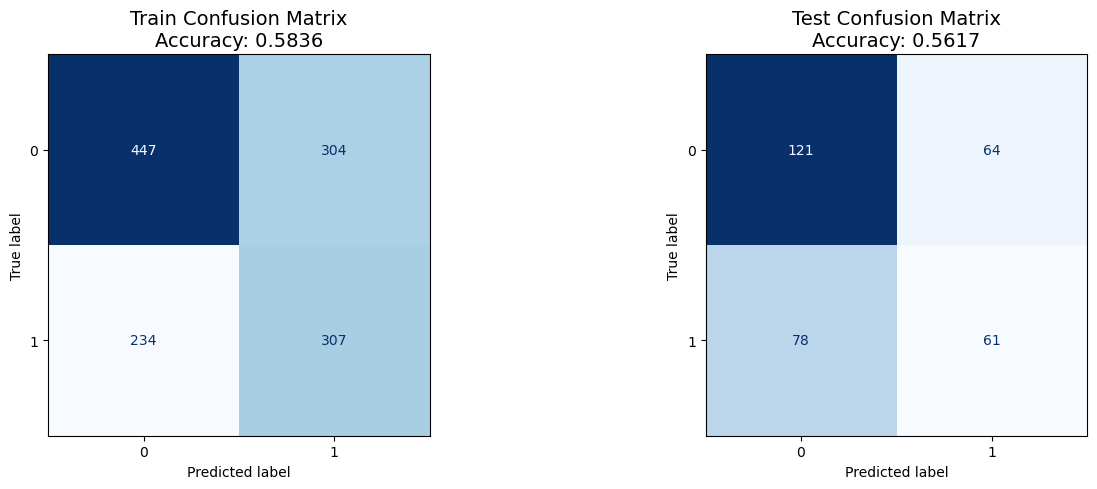


=== CONFUSION MATRIX DETAILS ===

Train Set:
  True Negatives (TN):  447
  False Positives (FP): 304
  False Negatives (FN): 234
  True Positives (TP):  307

Test Set:
  True Negatives (TN):  121
  False Positives (FP): 64
  False Negatives (FN): 78
  True Positives (TP):  61


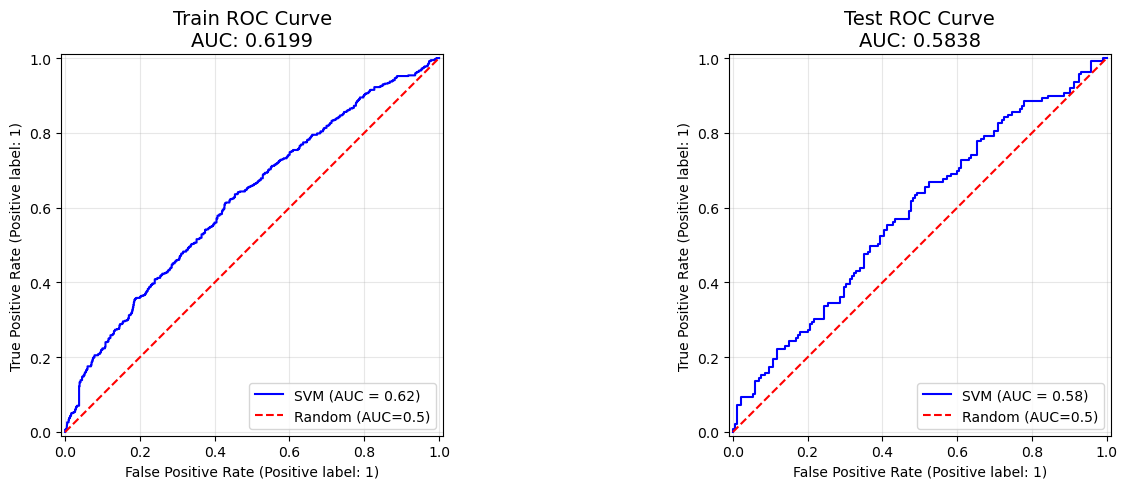

In [15]:
# 1. Get best model
best_model = svm_search.best_estimator_

# 2. Predictions on train/test using new pipeline
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# For ROC curve, need probability estimates
y_proba_train = best_model.predict_proba(X_train)[:, 1]
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 3. Accuracy Scores (Weighted)
print("=" * 60)
print("=== ACCURACY SCORES===")
print("=" * 60)
train_acc = accuracy_score(Y_train, y_pred_train)
test_acc = accuracy_score(Y_test, y_pred_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:             {test_acc:.4f}")
print(f"Difference:                {train_acc - test_acc:.4f}")

# 4. Additional Metrics (Weighted)
print("\n" + "=" * 60)
print("=== ADDITIONAL METRICS===")
print("=" * 60)
print(f"Train Precision: {precision_score(Y_train, y_pred_train):.4f}")
print(f"Test Precision:  {precision_score(Y_test, y_pred_test):.4f}")

print(f"Train Recall:    {recall_score(Y_train, y_pred_train):.4f}")
print(f"Test Recall:     {recall_score(Y_test, y_pred_test):.4f}")
print(f"Train F1:       {f1_score(Y_train, y_pred_train):.4f}")
print(f"Test F1:        {f1_score(Y_test, y_pred_test):.4f}")
print(f"Train AUC:      {roc_auc_score(Y_train, y_proba_train):.4f}")
print(f"Test AUC:       {roc_auc_score(Y_test, y_proba_test):.4f}")

# 6. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train confusion matrix
ConfusionMatrixDisplay.from_predictions(
    Y_train, 
    y_pred_train,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title(f'Train Confusion Matrix\nAccuracy: {train_acc:.4f}', fontsize=14)
axes[0].grid(False)

# Test confusion matrix
ConfusionMatrixDisplay.from_predictions(
    Y_test, 
    y_pred_test,
    ax=axes[1],
    cmap='Blues',
    colorbar=False
)
axes[1].set_title(f'Test Confusion Matrix\nAccuracy: {test_acc:.4f}', fontsize=14)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# 7. Print confusion matrix details
print("\n" + "=" * 60)
print("=== CONFUSION MATRIX DETAILS ===")
print("=" * 60)

cm_train = confusion_matrix(Y_train, y_pred_train)
cm_test = confusion_matrix(Y_test, y_pred_test)

print("\nTrain Set:")
print(f"  True Negatives (TN):  {cm_train[0,0]}")
print(f"  False Positives (FP): {cm_train[0,1]}")
print(f"  False Negatives (FN): {cm_train[1,0]}")
print(f"  True Positives (TP):  {cm_train[1,1]}")

print("\nTest Set:")
print(f"  True Negatives (TN):  {cm_test[0,0]}")
print(f"  False Positives (FP): {cm_test[0,1]}")
print(f"  False Negatives (FN): {cm_test[1,0]}")
print(f"  True Positives (TP):  {cm_test[1,1]}")

# 8. ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train ROC curve
RocCurveDisplay.from_predictions(
    Y_train,
    y_proba_train,
    ax=axes[0],
    name='SVM',
    color='blue'
)
axes[0].plot([0, 1], [0, 1], 'r--', label='Random (AUC=0.5)')
axes[0].set_title(f'Train ROC Curve\nAUC: {roc_auc_score(Y_train, y_proba_train):.4f}', fontsize=14)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Test ROC curve
RocCurveDisplay.from_predictions(
    Y_test,
    y_proba_test,
    ax=axes[1],
    name='SVM',
    color='blue'
)
axes[1].plot([0, 1], [0, 1], 'r--', label='Random (AUC=0.5)')
axes[1].set_title(f'Test ROC Curve\nAUC: {roc_auc_score(Y_test, y_proba_test):.4f}', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Strategy vs. Benchmark — Full Metric Comparison

`pyfolio`'s summary table only surfaces the benchmark through `Alpha`/`Beta` (the only two stats that are actually a function of both series) — it doesn't otherwise report the benchmark's own Sharpe, volatility, or drawdown alongside the strategy's. Computing `perf_stats` independently for both `Strategy` and `Returns` (buy-and-hold) gives a genuine side-by-side comparison rather than inferring it from alpha alone.

Both series here are built from `X_test` exclusively — the model's `.predict()` call never sees a row it was fit on, so this reflects genuinely out-of-sample performance, not the model reproducing patterns it was optimized against. An earlier draft of this notebook generated signals over the full dataset (train + test) before this step, which inflated the "backtest" segment with in-sample fit quality — worth naming explicitly since it's a natural mistake to make with `pyfolio`'s `live_start_date` argument (it only colors an existing return series by date, it has no awareness of where the model's own training boundary sits).

In [16]:
import pyfolio as pf
df3 = X_test.copy()
df3['Signal'] = best_model.predict(X_test)        # Using best SVM model

# Daily Returns - Benchmark return
df3['Returns'] = df3['RET'] 

# Strategy Returns - SVM
df3['Strategy'] = df3['Returns'] * df3['Signal'].shift(1).fillna(0)

strategy_stats = pf.timeseries.perf_stats(df3['Strategy'])
benchmark_stats = pf.timeseries.perf_stats(df3['Returns'])

comparison = pd.DataFrame({
    'Strategy': strategy_stats,
    'Benchmark': benchmark_stats
})
print(comparison)

                      Strategy  Benchmark
Annual return         0.228447   0.254571
Cumulative returns    0.302827   0.338556
Annual volatility     0.136126   0.180632
Sharpe ratio          1.578366   1.345494
Calmar ratio          3.447356   1.813003
Stability             0.784873   0.828630
Max drawdown         -0.066267  -0.140414
Omega ratio           1.689277   1.312158
Sortino ratio         2.992957   2.031883
Skew                  4.295110   1.037461
Kurtosis             58.078069  20.862189
Tail ratio            1.174514   0.980710
Daily value at risk  -0.016298  -0.021793


### Full tear sheet (out-of-sample only)

No `live_start_date` is passed — with signal generation restricted to `X_test`, there's no portion of this series that was seen during training, so there's no legitimate "backtest vs. live" split left to draw; the whole series is on equal, honest footing.

Start date,2025-03-14
End date,2026-06-29
Total months,15
,Backtest
Annual return,22.845%
Cumulative returns,30.283%
Annual volatility,13.613%
Sharpe ratio,1.58
Calmar ratio,3.45
Stability,0.78
Max drawdown,-6.627%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,6.63,2026-03-02,2026-03-30,2026-04-22,38
1,5.76,2025-03-26,2025-04-03,2025-04-09,11
2,2.92,2025-11-13,2025-11-20,2025-11-25,9
3,2.39,2025-07-29,2025-08-21,2025-10-15,57
4,2.33,2025-05-20,2025-05-23,2025-06-06,14


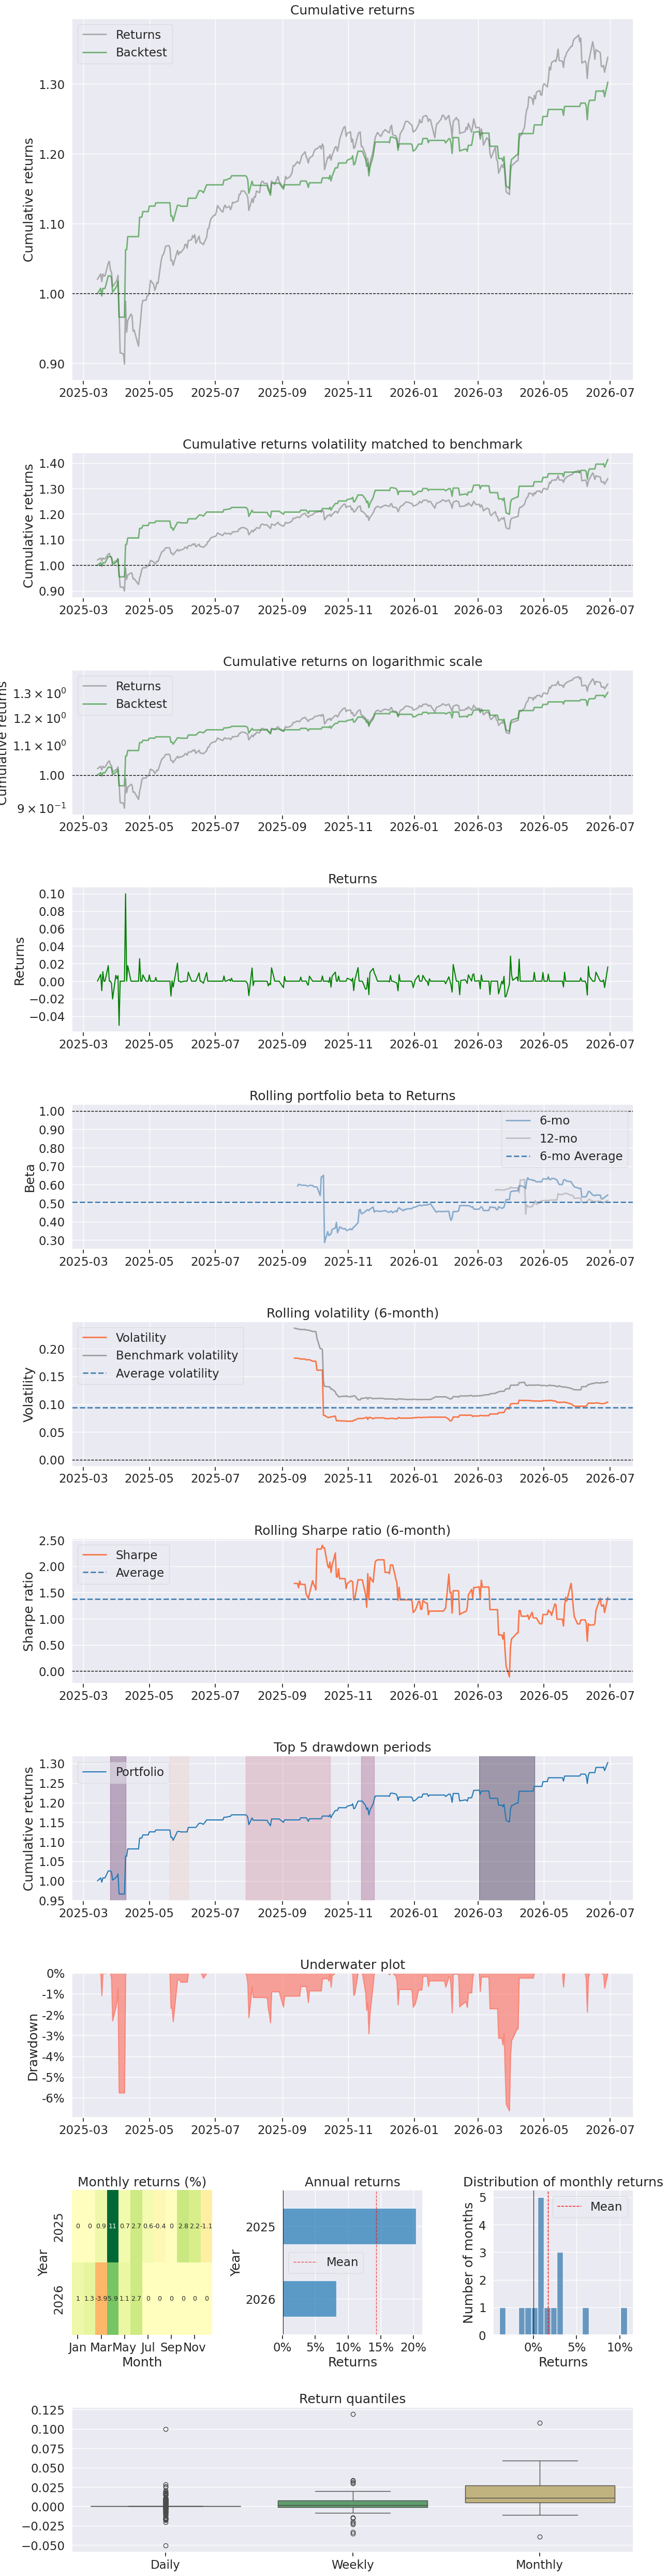

In [17]:
df2 = X_test.copy()
df2['Signal'] = best_model.predict(X_test)   # model never saw these rows during fit
df2['Returns'] = df2['RET']
df2['Strategy'] = df2['Returns'] * df2['Signal'].shift(1).fillna(0)
df2.index = df2.index.tz_localize('utc')

pf.create_returns_tear_sheet(
    df2['Strategy'],
    benchmark_rets=df2['Returns']
    # no live_start_date needed — the whole series is genuinely out-of-sample now
)

### Limitations and honest interpretation

- **Small out-of-sample sample.** The test period here is a single contiguous chronological slice. A Sharpe ratio (or any risk-adjusted metric) estimated over a short window carries wide statistical uncertainty — a single strong or weak out-of-sample stretch shouldn't be over-interpreted in either direction.
- **One train/test boundary tests one regime transition.** A more rigorous extension would be rolling/expanding walk-forward backtesting — retraining periodically on an expanding window and stitching together many honest out-of-sample periods, rather than trusting one static split.
- **Feature-selection is a greedy, staged approximation, not a joint global optimum.** Correlation filtering, Lasso selection, and scaler-bucket assignment are each fit once on `X_train` rather than being re-derived inside every CV fold or jointly optimized with the SVM's hyperparameters — a deliberate, documented compromise between rigor and tractable compute, not an oversight.
- **This is public daily OHLCV data with standard engineered features.** If a durable, easily-replicable trading edge existed here, it would likely already be arbitraged away. This notebook is intended to demonstrate leakage-free pipeline construction, feature engineering discipline, and honest evaluation methodology — not to claim tradeable alpha.